In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

from model import CACRT
from losses import CompetingRisksLoss, CIndexMetric, IntegratedBrierScore


# Set seeds for reproducibility
def set_seed(seed=42):
    torch.manual_seed(seed)
    np.random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [ ]:
# Load and Prepare UNOS Data


def load_and_prepare_data(filepath):
   
    df = pd.read_parquet(filepath)
    
    DONOR_FEATURES = [
        'AGE_DON', 'GENDER_DON', 'WGT_KG_DON_CALC',
        'HGT_CM_DON_CALC', 'BMI_DON_CALC', 'CREAT_DON',
        'HYPERTENS_DUR_DON', 'HIST_DIABETES_DON',
        'NON_HRT_DON', 'ECD_DONOR',
        'COD_CAD_DON_2.0', 'COD_CAD_DON_3.0', 'COD_CAD_DON_4.0',
    ]
    
    RECIPIENT_FEATURES = [
        'AGE', 'GENDER', 'WGT_KG_CALC', 'HGT_CM_CALC',
        'END_BMI_CALC', 'END_CPRA_DETAIL', 'FUNC_STAT_TRR',
        'DIAL_VINT_YEARS', 'NUM_PREV_TX', 'NPKID',
        'DIAB_2.0', 'DIAB_3.0', 'DIAB_4.0',
    ]
    
    MATCH_FEATURES = [
        'HLAMIS', 'COLD_ISCH_KI', 'PUMP_KI',
    ]
    

    # Validate columns exist
  
    all_features = DONOR_FEATURES + RECIPIENT_FEATURES + MATCH_FEATURES
    missing = [f for f in all_features if f not in df.columns]
    if missing:
        print(f" Missing columns: {missing}")
        print(f" Available columns: {list(df.columns)}")
        raise ValueError(f"Missing columns: {missing}")
    
  
    # Encode competing events

    # event: 0 = censored, 1 = graft failure, 2 = DWFG
    event = np.where(
        df['GSTATUS_KI'] == 0, 0,                    # Censored
        np.where(df['DWFG_KI'] == 1, 2, 1)           # DWFG=2, graft failure=1
    )
    durations = df['GTIME_YEARS'].values.astype('float32')
    
    # Extract feature matrices
    X_donor = df[DONOR_FEATURES].values.astype('float32')
    X_recip = df[RECIPIENT_FEATURES].values.astype('float32')
    X_match = df[MATCH_FEATURES].values.astype('float32')
    
    return X_donor, X_recip, X_match, durations, event, \
           DONOR_FEATURES, RECIPIENT_FEATURES, MATCH_FEATURES



In [ ]:
# Data Splitting and Preprocessing

def prepare_splits(X_donor, X_recip, X_match, durations, events):
    
    #Split into train/val/test (70/15/15) with stratification by event type
    #Standardize features (fit on train only)
    #Discretize survival times into bins
    
    # Stratified split 
    idx = np.arange(len(durations))
    idx_train, idx_temp, ev_train, ev_temp = train_test_split(
        idx, events, test_size=0.3, stratify=events, random_state=42
    )
    idx_val, idx_test, ev_val, ev_test = train_test_split(
        idx_temp, ev_temp, test_size=0.5, stratify=ev_temp, random_state=42
    )
    
    # Standardize (fit on train) 
    scaler_donor = StandardScaler()
    scaler_recip = StandardScaler()
    scaler_match = StandardScaler()
    
    X_d_train = scaler_donor.fit_transform(X_donor[idx_train])
    X_d_val = scaler_donor.transform(X_donor[idx_val])
    X_d_test = scaler_donor.transform(X_donor[idx_test])
    
    X_r_train = scaler_recip.fit_transform(X_recip[idx_train])
    X_r_val = scaler_recip.transform(X_recip[idx_val])
    X_r_test = scaler_recip.transform(X_recip[idx_test])
    
    X_m_train = scaler_match.fit_transform(X_match[idx_train])
    X_m_val = scaler_match.transform(X_match[idx_val])
    X_m_test = scaler_match.transform(X_match[idx_test])
    
    dur_train = durations[idx_train]
    dur_val = durations[idx_val]
    dur_test = durations[idx_test]
    
    ev_train = events[idx_train]
    ev_val = events[idx_val]
    ev_test = events[idx_test]
    
    # Discretize time into bins 
    NUM_TIME_BINS = 100
    # Create equidistant grid from 0 to max observed time
    time_grid = np.linspace(0, dur_train.max(), NUM_TIME_BINS + 1)[1:]  # bin edges
    
    # map continuous times to bin indices
    dur_train_disc = np.digitize(dur_train, time_grid).astype('int64')
    dur_val_disc = np.digitize(dur_val, time_grid).astype('int64')
    dur_test_disc = np.digitize(dur_test, time_grid).astype('int64')
    
    # Clamp to valid range [0, NUM_TIME_BINS-1]
    dur_train_disc = np.clip(dur_train_disc, 0, NUM_TIME_BINS - 1)
    dur_val_disc = np.clip(dur_val_disc, 0, NUM_TIME_BINS - 1)
    dur_test_disc = np.clip(dur_test_disc, 0, NUM_TIME_BINS - 1)
    
    data = {
        'train': {
            'donor': torch.FloatTensor(X_d_train),
            'recip': torch.FloatTensor(X_r_train),
            'match': torch.FloatTensor(X_m_train),
            'durations': torch.LongTensor(dur_train_disc),
            'events': torch.LongTensor(ev_train),
            'durations_raw': dur_train,
        },
        'val': {
            'donor': torch.FloatTensor(X_d_val),
            'recip': torch.FloatTensor(X_r_val),
            'match': torch.FloatTensor(X_m_val),
            'durations': torch.LongTensor(dur_val_disc),
            'events': torch.LongTensor(ev_val),
            'durations_raw': dur_val,
        },
        'test': {
            'donor': torch.FloatTensor(X_d_test),
            'recip': torch.FloatTensor(X_r_test),
            'match': torch.FloatTensor(X_m_test),
            'durations': torch.LongTensor(dur_test_disc),
            'events': torch.LongTensor(ev_test),
            'durations_raw': dur_test,
        },
        'time_grid': time_grid,
        'num_time_bins': NUM_TIME_BINS,
        'scalers': (scaler_donor, scaler_recip, scaler_match),
    }
    
    # Print summary
    for split_name in ['train', 'val', 'test']:
        ev = data[split_name]['events'].numpy()
        n = len(ev)
        print(f"{split_name:5s}: n={n:6d} | "
              f"censored={np.sum(ev==0):5d} ({np.mean(ev==0)*100:.1f}%) | "
              f"graft_fail={np.sum(ev==1):5d} ({np.mean(ev==1)*100:.1f}%) | "
              f"DWFG={np.sum(ev==2):5d} ({np.mean(ev==2)*100:.1f}%)")
    
    return data

In [4]:
# Create DataLoaders

class SurvivalDataset(Dataset):
    """Custom dataset for competing risks survival data"""
    def __init__(self, donor, recip, match, durations, events):
        self.donor = donor
        self.recip = recip
        self.match = match
        self.durations = durations
        self.events = events
    
    def __len__(self):
        return len(self.durations)
    
    def __getitem__(self, idx):
        return (self.donor[idx], self.recip[idx], self.match[idx],
                self.durations[idx], self.events[idx])


def create_dataloaders(data, batch_size=512):
    train_ds = SurvivalDataset(
        data['train']['donor'], data['train']['recip'], data['train']['match'],
        data['train']['durations'], data['train']['events']
    )
    val_ds = SurvivalDataset(
        data['val']['donor'], data['val']['recip'], data['val']['match'],
        data['val']['durations'], data['val']['events']
    )
    test_ds = SurvivalDataset(
        data['test']['donor'], data['test']['recip'], data['test']['match'],
        data['test']['durations'], data['test']['events']
    )
    
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,
                              num_workers=0, pin_memory=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size * 2, shuffle=False,
                            num_workers=0, pin_memory=True)
    test_loader = DataLoader(test_ds, batch_size=batch_size * 2, shuffle=False,
                             num_workers=0, pin_memory=True)
    
    return train_loader, val_loader, test_loader

In [5]:
#Training Loop

def train_epoch(model, loader, criterion, optimizer, device):
    """Train for one epoch."""
    model.train()
    total_loss = 0
    total_nll = 0
    total_rank = 0
    n_batches = 0
    
    for donor, recip, match, dur, evt in loader:
        donor = donor.to(device)
        recip = recip.to(device)
        match = match.to(device)
        dur = dur.to(device)
        evt = evt.to(device)
        
        optimizer.zero_grad()
        pmf, cif, surv = model(donor, recip, match)
        loss, nll, rank = criterion(pmf, cif, surv, dur, evt)
        
        loss.backward()
        # Gradient clipping — important for transformer stability
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        total_loss += loss.item()
        total_nll += nll.item()
        total_rank += rank.item()
        n_batches += 1
    
    return total_loss / n_batches, total_nll / n_batches, total_rank / n_batches


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    """Evaluate on validation/test set."""
    model.eval()
    total_loss = 0
    total_nll = 0
    total_rank = 0
    n_batches = 0
    
    all_cif = []
    all_dur = []
    all_evt = []
    
    for donor, recip, match, dur, evt in loader:
        donor = donor.to(device)
        recip = recip.to(device)
        match = match.to(device)
        dur = dur.to(device)
        evt = evt.to(device)
        
        pmf, cif, surv = model(donor, recip, match)
        loss, nll, rank = criterion(pmf, cif, surv, dur, evt)
        
        total_loss += loss.item()
        total_nll += nll.item()
        total_rank += rank.item()
        n_batches += 1
        
        all_cif.append(cif.cpu())
        all_dur.append(dur.cpu())
        all_evt.append(evt.cpu())
    
    all_cif = torch.cat(all_cif, dim=0)
    all_dur = torch.cat(all_dur, dim=0)
    all_evt = torch.cat(all_evt, dim=0)
    
    # Compute C-index for each cause (on a sample for speed)
    n_eval = min(15000, len(all_dur))
    sample_idx = np.random.choice(len(all_dur), n_eval, replace=False)
    
    c_graft = CIndexMetric.compute(
        all_cif[sample_idx], all_dur[sample_idx], all_evt[sample_idx], cause=1
    )
    c_dwfg = CIndexMetric.compute(
        all_cif[sample_idx], all_dur[sample_idx], all_evt[sample_idx], cause=2
    )
    
    avg_loss = total_loss / n_batches
    
    return avg_loss, total_nll / n_batches, total_rank / n_batches, c_graft, c_dwfg




In [6]:
def train_model(model, train_loader, val_loader, config, device):
    """
    Full training loop with early stopping, LR scheduling, and logging.
    """
    criterion = CompetingRisksLoss(
        alpha=config['alpha'],
        sigma=config['sigma'],
        num_risks=config['num_risks']
    )
    
    optimizer = optim.AdamW(
        model.parameters(),
        lr=config['lr'],
        weight_decay=config['weight_decay']
    )
    
    scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer, T_0=20, T_mult=2, eta_min=1e-6
    )
    
    # Early stopping
    best_val_loss = float('inf')
    best_val_c_graft = 0
    patience_counter = 0
    best_model_state = None
    
    history = {
        'train_loss': [], 'val_loss': [],
        'train_nll': [], 'val_nll': [],
        'train_rank': [], 'val_rank': [],
        'val_c_graft': [], 'val_c_dwfg': [],
        'lr': []
    }
    
    print(f"\n{'='*80}")
    print(f"Training CACRTransformer")
    print(f"{'='*80}")
    print(f"{'Epoch':>5} | {'Train Loss':>10} | {'Val Loss':>10} | "
          f"{'C_graft':>8} | {'C_DWFG':>8} | {'LR':>10} | {'Status':>10}")
    print(f"{'-'*80}")
    
    for epoch in range(config['max_epochs']):
        # Train
        train_loss, train_nll, train_rank = train_epoch(
            model, train_loader, criterion, optimizer, device
        )
        
        # Validate
        val_loss, val_nll, val_rank, c_graft, c_dwfg = evaluate(
            model, val_loader, criterion, device
        )
        
        # LR scheduling
        scheduler.step()
        current_lr = optimizer.param_groups[0]['lr']
        
        # Log
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_nll'].append(train_nll)
        history['val_nll'].append(val_nll)
        history['train_rank'].append(train_rank)
        history['val_rank'].append(val_rank)
        history['val_c_graft'].append(c_graft)
        history['val_c_dwfg'].append(c_dwfg)
        history['lr'].append(current_lr)
        
        # Early stopping (based on validation C-index for graft failure)
        status = ""
        if c_graft > best_val_c_graft:
            best_val_c_graft = c_graft
            best_val_loss = val_loss
            best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
            status = "★ BEST"
        else:
            patience_counter += 1
            if patience_counter >= config['patience']:
                print(f"\nEarly stopping at epoch {epoch+1} "
                      f"(best C_graft: {best_val_c_graft:.4f})")
                break
        
        if (epoch + 1) % 5 == 0 or status:
            print(f"{epoch+1:5d} | {train_loss:10.4f} | {val_loss:10.4f} | "
                  f"{c_graft:8.4f} | {c_dwfg:8.4f} | {current_lr:10.6f} | {status:>10}")
    
    # Restore best model
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
        model.to(device)
    
    return model, history

In [7]:
# Visualization Functions

def plot_training_history(history):
    """Plot training curves."""
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Loss curves
    axes[0, 0].plot(history['train_loss'], label='Train', alpha=0.8)
    axes[0, 0].plot(history['val_loss'], label='Val', alpha=0.8)
    axes[0, 0].set_title('Total Loss')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # NLL vs Ranking loss
    axes[0, 1].plot(history['train_nll'], label='NLL (train)', alpha=0.8)
    axes[0, 1].plot(history['train_rank'], label='Rank (train)', alpha=0.8)
    axes[0, 1].set_title('Loss Components (Train)')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # C-index
    axes[1, 0].plot(history['val_c_graft'], label='Graft Failure', color='#e74c3c')
    axes[1, 0].plot(history['val_c_dwfg'], label='DWFG', color='#3498db')
    axes[1, 0].set_title('Validation C-index (cause-specific)')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Random')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    # Learning rate
    axes[1, 1].plot(history['lr'], color='#2ecc71')
    axes[1, 1].set_title('Learning Rate Schedule')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_yscale('log')
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
    plt.show()

In [ ]:
def plot_cif_curves(model, data, device, n_patients=5):
    """Plot individual patient CIF curves for both competing risks"""
    model.eval()
    
    # Pick random test patients
    n_test = len(data['test']['donor'])
    idx = np.random.choice(n_test, n_patients, replace=False)
    
    with torch.no_grad():
        donor = data['test']['donor'][idx].to(device)
        recip = data['test']['recip'][idx].to(device)
        match = data['test']['match'][idx].to(device)
        
        pmf, cif, surv = model(donor, recip, match)
        cif = cif.cpu().numpy()
        surv = surv.cpu().numpy()
    
    time_grid = data['time_grid']
    events = data['test']['events'][idx].numpy()
    durs = data['test']['durations'][idx].numpy()
    
    fig, axes = plt.subplots(1, n_patients, figsize=(5 * n_patients, 4), sharey=True)
    if n_patients == 1:
        axes = [axes]
    
    for i, ax in enumerate(axes):
        # CIF for graft failure (cause 1)
        ax.plot(time_grid, cif[i, 0, :], color='#e74c3c', linewidth=2,
                label='Graft Failure')
        ax.fill_between(time_grid, 0, cif[i, 0, :], alpha=0.15, color='#e74c3c')
        
        # CIF for DWFG (cause 2)
        ax.plot(time_grid, cif[i, 1, :], color='#3498db', linewidth=2,
                label='DWFG')
        ax.fill_between(time_grid, cif[i, 0, :],
                       cif[i, 0, :] + cif[i, 1, :], alpha=0.15, color='#3498db')
        
        # Mark actual event
        event_names = {0: 'Censored', 1: 'Graft Fail', 2: 'DWFG'}
        event_colors = {0: 'gray', 1: '#e74c3c', 2: '#3498db'}
        t_idx = min(durs[i], len(time_grid) - 1)
        ax.axvline(x=time_grid[t_idx], color=event_colors[events[i]],
                  linestyle='--', alpha=0.7)
        ax.set_title(f'Patient {idx[i]}\n({event_names[events[i]]})', fontsize=10)
        ax.set_xlabel('Time')
        if i == 0:
            ax.set_ylabel('Cumulative Incidence')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
        ax.set_ylim(0, 1)
    
    plt.suptitle('Patient-Level Competing Risks CIF', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.savefig('cif_curves.png', dpi=150, bbox_inches='tight')
    plt.show()

In [ ]:
def plot_attention_heatmap(model, data, device, donor_features, recip_features):
    """Visualize cross-attention weights for interpretability"""
    model.eval()
    
    # Run a small batch to get attention weights
    with torch.no_grad():
        donor = data['test']['donor'][:32].to(device)
        recip = data['test']['recip'][:32].to(device)
        match = data['test']['match'][:32].to(device)
        
        _ = model(donor, recip, match)
        attn_weights = model.get_cross_attention_weights()
    
    # Average attention weights over batch and heads
    # Last cross-attention layer
    d2r = attn_weights[-1]['donor_to_recip'].mean(dim=0).numpy()
    r2d = attn_weights[-1]['recip_to_donor'].mean(dim=0).numpy()
    
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    
    # Donor → Recipient attention
    sns.heatmap(d2r, ax=axes[0], cmap='YlOrRd',
                xticklabels=recip_features, yticklabels=donor_features,
                annot=False, fmt='.2f')
    axes[0].set_title('Donor attending to Recipient features')
    axes[0].set_xlabel('Recipient Features')
    axes[0].set_ylabel('Donor Features')
    
    # Recipient → Donor attention
    sns.heatmap(r2d, ax=axes[1], cmap='YlOrRd',
                xticklabels=donor_features, yticklabels=recip_features,
                annot=False, fmt='.2f')
    axes[1].set_title('Recipient attending to Donor features')
    axes[1].set_xlabel('Donor Features')
    axes[1].set_ylabel('Recipient Features')
    
    plt.suptitle('Cross-Attention Weights (interpretability)', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.savefig('attention_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()

Configuration and Main Execution

In [ ]:

# MODEL AND TRAINING CONFIGURATION

CONFIG = {
    
    'data_path': 'C:/Users/olf3ph/Music/dd/New folder/graft_preproc_encod.parquet',  
    
    # architecture 
    'd_model': 48,           # Embedding dimension per feature
    'n_heads': 4,            # Attention heads (must divide d_model)
    'n_self_layers': 2,      # Self-attention layers per stream
    'n_cross_layers': 1,     # Cross-attention layers
    'd_ff': 96,             # FFN hidden dim
    'dropout': 0.20,         # Dropout rate
    'num_risks': 2,          # Graft failure + DWFG
    'num_time_bins': 100,    # Time discretization granularity
    
    # Training 
    'batch_size': 1024,       # 143k / 512 ≈ 280 steps per epoch
    'lr': 3e-4,              # Initial learning rate
    'weight_decay': 3e-4,    # L2 regularization
    'max_epochs': 300,       # Maximum training epochs
    'patience': 35,          # Early stopping patience
    
    #  Loss 
    'alpha': 0.25,            # Ranking loss weight (0 = pure NLL)
    'sigma': 0.1,            # Ranking loss smoothness
}

In [ ]:
def main():
   
    # Load data
    print("Loading and preparing data...")
    print("-" * 60)
    X_donor, X_recip, X_match, durations, events, \
        donor_feats, recip_feats, match_feats = load_and_prepare_data(CONFIG['data_path'])
    
    n_donor = X_donor.shape[1]
    n_recip = X_recip.shape[1]
    n_match = X_match.shape[1]
    
    print(f"\nFeature groups:")
    print(f"  Donor:     {n_donor} features → {donor_feats}")
    print(f"  Recipient: {n_recip} features → {recip_feats}")
    print(f"  Match:     {n_match} features → {match_feats}")
    print(f"  Total:     {n_donor + n_recip + n_match} features")
    print(f"\nEvent distribution:")
    for evt_val, evt_name in [(0, 'Censored'), (1, 'Graft Failure'), (2, 'DWFG')]:
        count = np.sum(events == evt_val)
        print(f"  {evt_name}: {count} ({count/len(events)*100:.1f}%)")
    
    # Prepare splits
    print("Splitting and standardizing...")
    print("-" * 60)
    data = prepare_splits(X_donor, X_recip, X_match, durations, events)
    
    # Create dataloaders
    train_loader, val_loader, test_loader = create_dataloaders(
        data, batch_size=CONFIG['batch_size']
    )
    
    # Initialize model
    print(f"\n{'-'*60}")
    print(" Initializing CACRT...")
    print("-" * 60)
    model = CACRT(
        n_donor_features=n_donor,
        n_recip_features=n_recip,
        n_match_features=n_match,
        d_model=CONFIG['d_model'],
        n_heads=CONFIG['n_heads'],
        n_self_layers=CONFIG['n_self_layers'],
        n_cross_layers=CONFIG['n_cross_layers'],
        d_ff=CONFIG['d_ff'],
        num_risks=CONFIG['num_risks'],
        num_time_bins=CONFIG['num_time_bins'],
        dropout=CONFIG['dropout']
    ).to(device)
    
    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"  Model parameters: {n_params:,}")
    print(f"  Device: {device}")
    
    # Train
    print(f"\n{'-'*60}")
    print("Training...")
    print("-" * 60)
    model, history = train_model(model, train_loader, val_loader, CONFIG, device)
    
    # Evaluate on test set
    print(f"\n{'-'*60}")
    print("Final evaluation on test set...")
    print("-" * 60)
    criterion = CompetingRisksLoss(
        alpha=CONFIG['alpha'], sigma=CONFIG['sigma'], num_risks=CONFIG['num_risks']
    )
    test_loss, test_nll, test_rank, test_c_graft, test_c_dwfg = evaluate(
        model, test_loader, criterion, device
    )
    print(f"\n  Test Loss:       {test_loss:.4f}")
    print(f"  Test C_graft:    {test_c_graft:.4f}")
    print(f"  Test C_DWFG:     {test_c_dwfg:.4f}")
    
    # Visualizations
    print(f"\n{'-'*60}")
    print("Generating visualizations...")
    print("-" * 60)
    plot_training_history(history)
    plot_cif_curves(model, data, device)
    plot_attention_heatmap(model, data, device, donor_feats, recip_feats)
    
    # Save model
    torch.save({
        'model_state_dict': model.state_dict(),
        'config': CONFIG,
        'history': history,
        'feature_names': {
            'donor': donor_feats,
            'recipient': recip_feats,
            'match': match_feats
        }
    }, 'cacr_transformer_best.pt')
    print("\nModel saved to cacr_transformer_best.pt")
    
    return model, history, data


Loading and preparing data...
------------------------------------------------------------

Feature groups:
  Donor:     13 features → ['AGE_DON', 'GENDER_DON', 'WGT_KG_DON_CALC', 'HGT_CM_DON_CALC', 'BMI_DON_CALC', 'CREAT_DON', 'HYPERTENS_DUR_DON', 'HIST_DIABETES_DON', 'NON_HRT_DON', 'ECD_DONOR', 'COD_CAD_DON_2.0', 'COD_CAD_DON_3.0', 'COD_CAD_DON_4.0']
  Recipient: 13 features → ['AGE', 'GENDER', 'WGT_KG_CALC', 'HGT_CM_CALC', 'END_BMI_CALC', 'END_CPRA_DETAIL', 'FUNC_STAT_TRR', 'DIAL_VINT_YEARS', 'NUM_PREV_TX', 'NPKID', 'DIAB_2.0', 'DIAB_3.0', 'DIAB_4.0']
  Match:     3 features → ['HLAMIS', 'COLD_ISCH_KI', 'PUMP_KI']
  Total:     29 features

Event distribution:
  Censored: 100500 (73.7%)
  Graft Failure: 16574 (12.1%)
  DWFG: 19368 (14.2%)
Splitting and standardizing...
------------------------------------------------------------
train: n= 95509 | censored=70350 (73.7%) | graft_fail=11602 (12.1%) | DWFG=13557 (14.2%)
val  : n= 20466 | censored=15075 (73.7%) | graft_fail= 2486 (12.1%) 

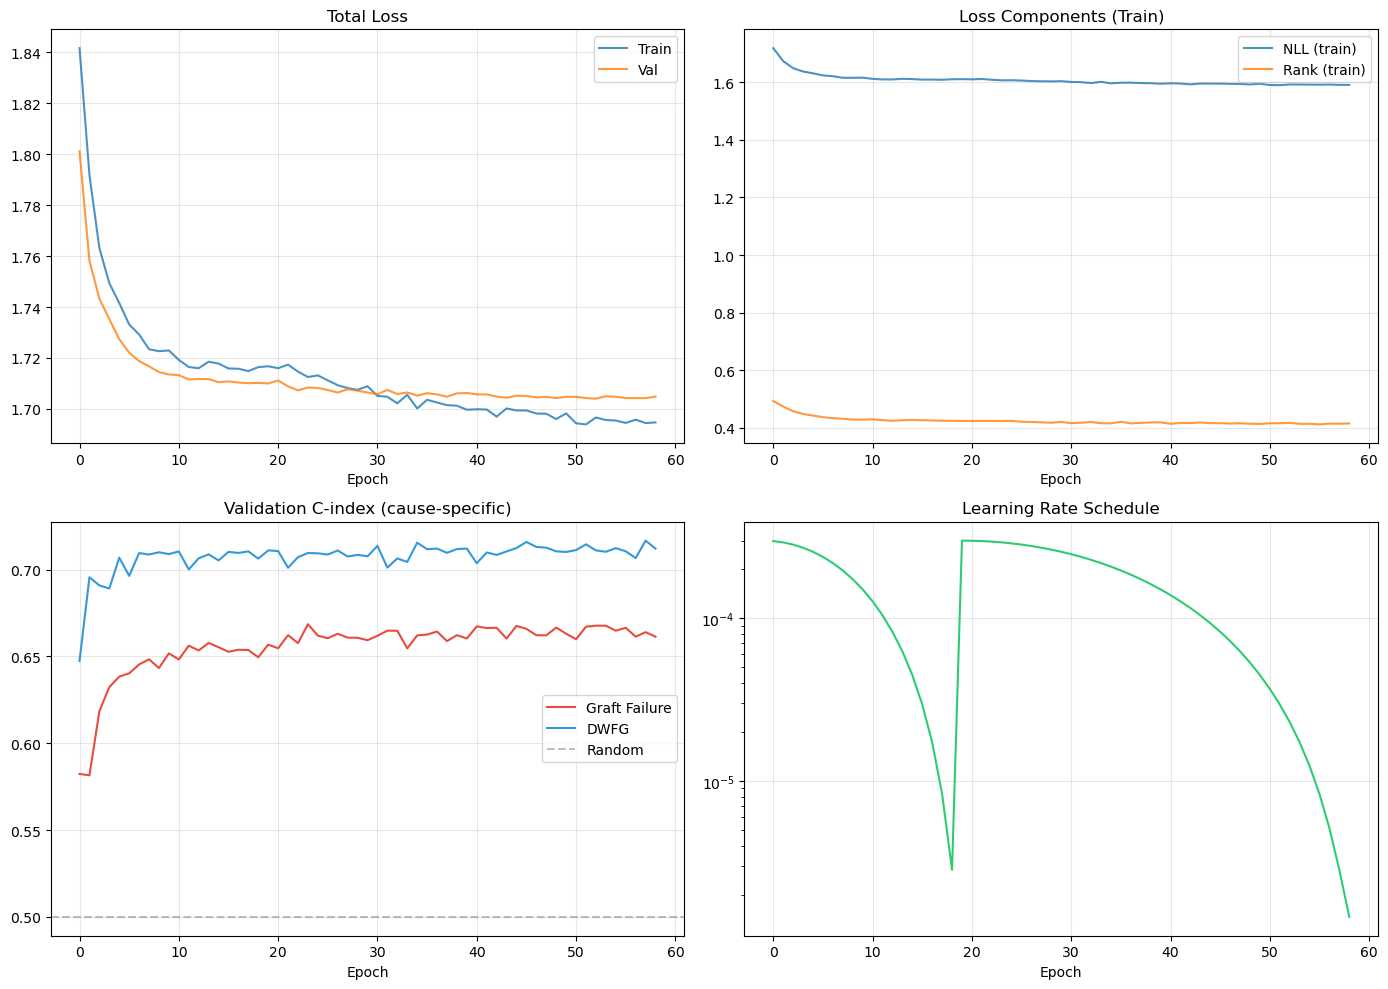

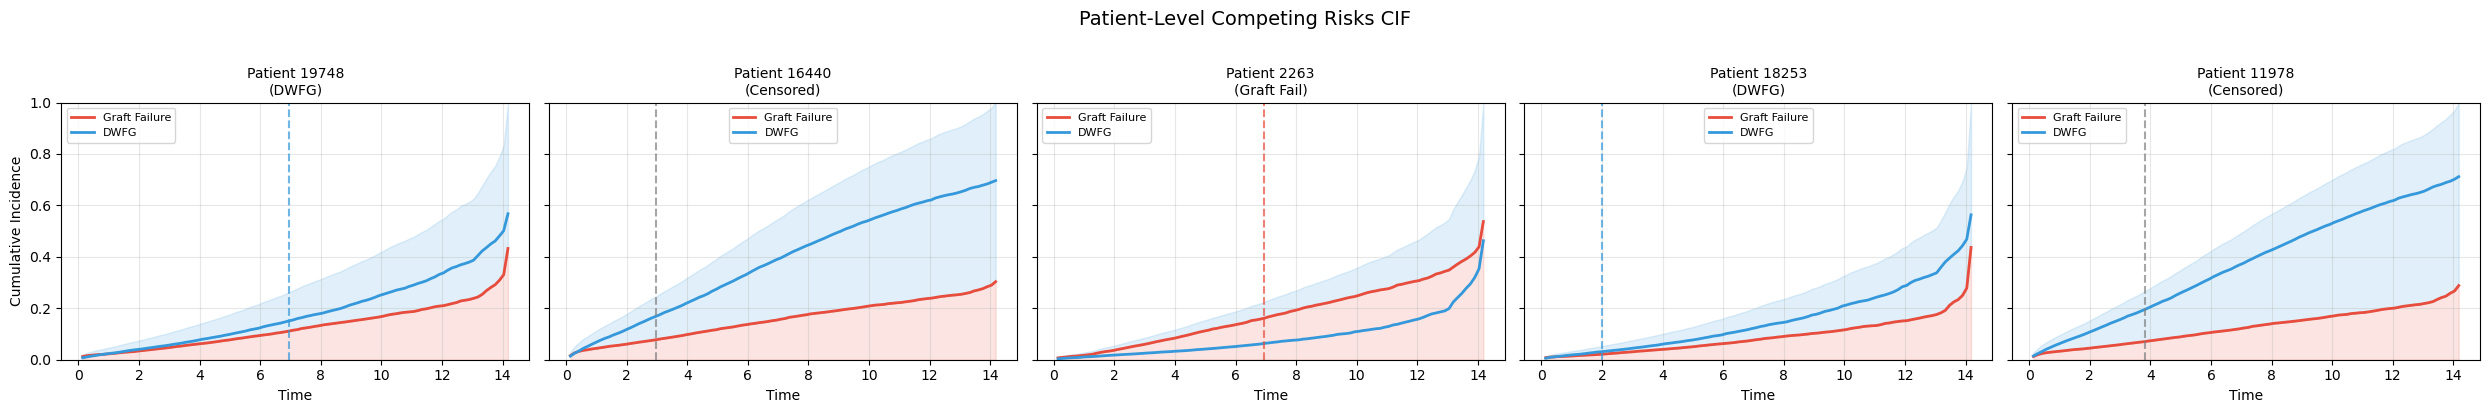

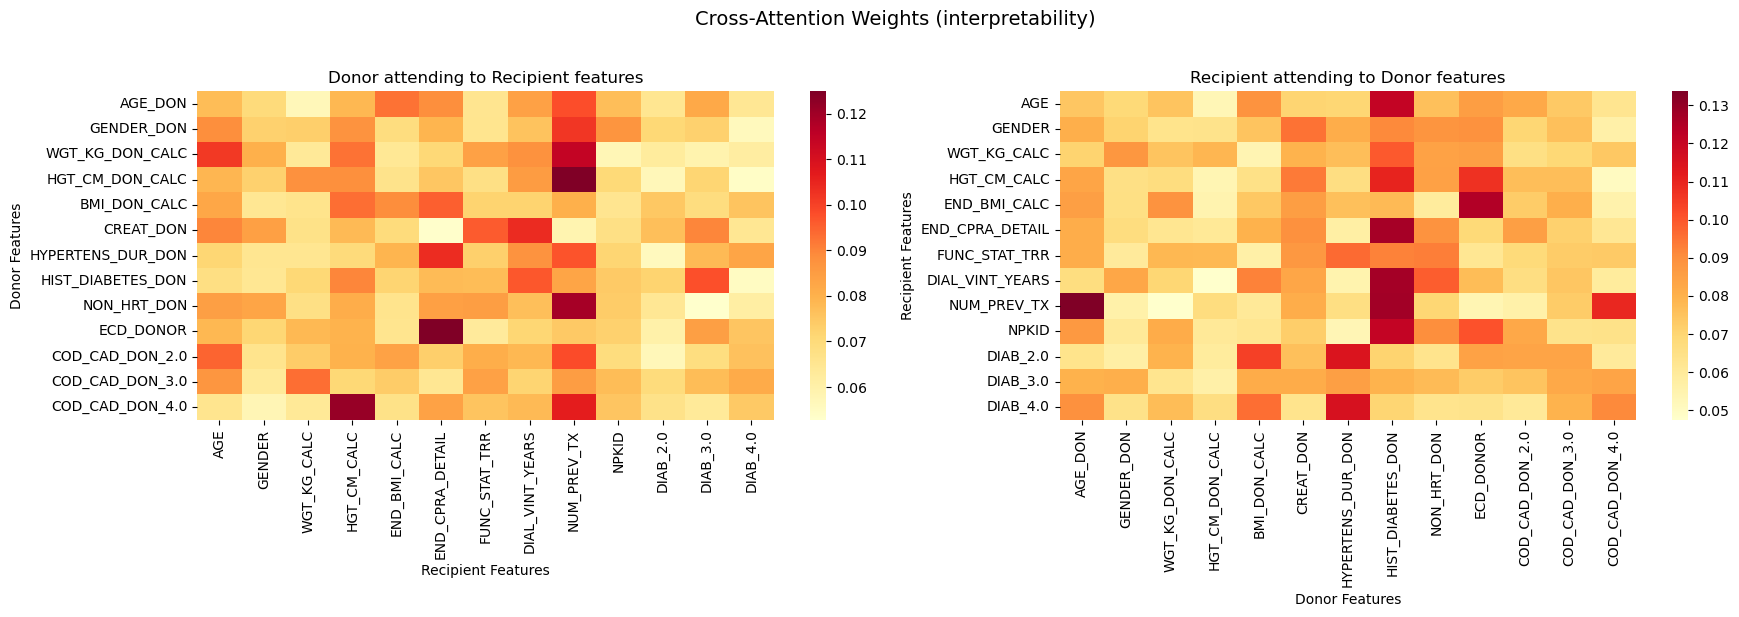


Model saved to cacr_transformer_best.pt


In [12]:
if __name__ == '__main__':
    model, history, data = main()

In [ ]:
# Optuna Hyperparameter Tuning ()
def run_optuna_tuning(data, n_trials=50):
    """
    hyperparameter search using Optuna.
    """
    import optuna
    
    train_loader, val_loader, _ = create_dataloaders(data, batch_size=1024)
    
    def objective(trial):
        config = {
            'd_model': trial.suggest_categorical('d_model', [32, 64, 128]),
            'n_heads': trial.suggest_categorical('n_heads', [2, 4, 8]),
            'n_self_layers': trial.suggest_int('n_self_layers', 1, 4),
            'n_cross_layers': trial.suggest_int('n_cross_layers', 1, 3),
            'd_ff': trial.suggest_categorical('d_ff', [64, 128, 256]),
            'dropout': trial.suggest_float('dropout', 0.05, 0.3),
            'lr': trial.suggest_float('lr', 1e-5, 1e-2, log=True),
            'weight_decay': trial.suggest_float('weight_decay', 1e-6, 1e-3, log=True),
            'alpha': trial.suggest_float('alpha', 0.0, 0.5),
            'sigma': trial.suggest_float('sigma', 0.01, 1.0, log=True),
            'num_risks': 2,
            'num_time_bins': data['num_time_bins'],
            'max_epochs': 80,
            'patience': 15,
            'batch_size': 512,
        }
        
        # Ensure n_heads divides d_model
        if config['d_model'] % config['n_heads'] != 0:
            raise optuna.TrialPruned()
        
        model = CACRTransformer(
            n_donor_features=data['train']['donor'].size(1),
            n_recip_features=data['train']['recip'].size(1),
            n_match_features=data['train']['match'].size(1),
            **{k: config[k] for k in ['d_model', 'n_heads', 'n_self_layers',
                                       'n_cross_layers', 'd_ff', 'dropout',
                                       'num_risks', 'num_time_bins']}
        ).to(device)
        
        model, history = train_model(model, train_loader, val_loader, config, device)
        
        return max(history['val_c_graft'])
    
    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=n_trials)
    
    print(f"\nBest C_graft: {study.best_value:.4f}")
    print(f"Best params: {study.best_params}")
    
    return study

In [14]:
study = run_optuna_tuning(data, n_trials=50)

[I 2026-04-15 00:39:10,789] A new study created in memory with name: no-name-2e7a2d8e-20ac-4f57-bb21-e063ab0e66bc



Training CACRTransformer
Epoch | Train Loss |   Val Loss |  C_graft |   C_DWFG |         LR |     Status
--------------------------------------------------------------------------------
    1 |     1.8398 |     1.8094 |   0.5600 |   0.6409 |   0.000037 |     ★ BEST
    2 |     1.8126 |     1.7894 |   0.5893 |   0.6698 |   0.000036 |     ★ BEST
    3 |     1.7923 |     1.7708 |   0.5942 |   0.6871 |   0.000035 |     ★ BEST
    4 |     1.7737 |     1.7571 |   0.5985 |   0.6921 |   0.000034 |     ★ BEST
    5 |     1.7605 |     1.7475 |   0.6018 |   0.6984 |   0.000032 |     ★ BEST
    6 |     1.7520 |     1.7414 |   0.6150 |   0.6932 |   0.000030 |     ★ BEST
    7 |     1.7477 |     1.7371 |   0.6312 |   0.6981 |   0.000027 |     ★ BEST
    8 |     1.7432 |     1.7319 |   0.6312 |   0.6937 |   0.000025 |     ★ BEST
    9 |     1.7403 |     1.7288 |   0.6360 |   0.6979 |   0.000022 |     ★ BEST
   10 |     1.7344 |     1.7273 |   0.6300 |   0.7082 |   0.000019 |           
   11 |     1

[I 2026-04-15 01:40:44,818] Trial 0 finished with value: 0.666985503560052 and parameters: {'d_model': 128, 'n_heads': 8, 'n_self_layers': 4, 'n_cross_layers': 3, 'd_ff': 128, 'dropout': 0.19864243434992523, 'lr': 3.7208468125903594e-05, 'weight_decay': 4.046643883544869e-06, 'alpha': 0.20246960955271287, 'sigma': 0.6449703864994496}. Best is trial 0 with value: 0.666985503560052.



Early stopping at epoch 66 (best C_graft: 0.6670)

Training CACRTransformer
Epoch | Train Loss |   Val Loss |  C_graft |   C_DWFG |         LR |     Status
--------------------------------------------------------------------------------
    1 |     1.9915 |     1.9614 |   0.5281 |   0.6201 |   0.000068 |     ★ BEST
    2 |     1.9624 |     1.9343 |   0.5465 |   0.6769 |   0.000067 |     ★ BEST
    3 |     1.9336 |     1.9113 |   0.5583 |   0.6878 |   0.000065 |     ★ BEST
    4 |     1.9116 |     1.8921 |   0.5682 |   0.6991 |   0.000062 |     ★ BEST
    5 |     1.8972 |     1.8801 |   0.5828 |   0.6958 |   0.000058 |     ★ BEST
    6 |     1.8830 |     1.8706 |   0.6092 |   0.6933 |   0.000054 |     ★ BEST
    7 |     1.8749 |     1.8609 |   0.6111 |   0.7007 |   0.000050 |     ★ BEST
    8 |     1.8686 |     1.8554 |   0.6198 |   0.7025 |   0.000045 |     ★ BEST
    9 |     1.8625 |     1.8503 |   0.6329 |   0.7028 |   0.000040 |     ★ BEST
   10 |     1.8565 |     1.8461 |   0.6287

[I 2026-04-15 02:38:55,606] Trial 1 finished with value: 0.6681818674445742 and parameters: {'d_model': 64, 'n_heads': 2, 'n_self_layers': 2, 'n_cross_layers': 2, 'd_ff': 128, 'dropout': 0.16678621562356782, 'lr': 6.833826379366083e-05, 'weight_decay': 2.0742397588344727e-06, 'alpha': 0.4929341034913123, 'sigma': 0.09411264967429789}. Best is trial 1 with value: 0.6681818674445742.


...


Early stopping at epoch 60 (best C_graft: 0.6454)

Training CACRTransformer
Epoch | Train Loss |   Val Loss |  C_graft |   C_DWFG |         LR |     Status
--------------------------------------------------------------------------------
    1 |     1.8914 |     1.8642 |   0.5387 |   0.5405 |   0.000044 |     ★ BEST
    2 |     1.8794 |     1.8570 |   0.5542 |   0.5604 |   0.000043 |     ★ BEST
    3 |     1.8706 |     1.8511 |   0.5722 |   0.5808 |   0.000042 |     ★ BEST
    4 |     1.8626 |     1.8453 |   0.5723 |   0.6070 |   0.000040 |     ★ BEST
    5 |     1.8544 |     1.8401 |   0.5805 |   0.6049 |   0.000038 |     ★ BEST
    7 |     1.8428 |     1.8307 |   0.5806 |   0.6370 |   0.000032 |     ★ BEST
    8 |     1.8339 |     1.8266 |   0.5853 |   0.6450 |   0.000029 |     ★ BEST
   10 |     1.8280 |     1.8187 |   0.5763 |   0.6659 |   0.000022 |           
   15 |     1.8188 |     1.8106 |   0.5759 |   0.6720 |   0.000007 |           
   20 |     1.8186 |     1.8086 |   0.5792

[I 2026-04-16 08:49:40,894] Trial 48 finished with value: 0.5852772440855111 and parameters: {'d_model': 64, 'n_heads': 8, 'n_self_layers': 1, 'n_cross_layers': 1, 'd_ff': 256, 'dropout': 0.28745207788835886, 'lr': 4.393789345247928e-05, 'weight_decay': 0.00016668450535641617, 'alpha': 0.3020079617911009, 'sigma': 0.3830298993286758}. Best is trial 15 with value: 0.6745947443040041.



Early stopping at epoch 23 (best C_graft: 0.5853)

Training CACRTransformer
Epoch | Train Loss |   Val Loss |  C_graft |   C_DWFG |         LR |     Status
--------------------------------------------------------------------------------
    1 |     1.8745 |     1.8016 |   0.6321 |   0.7025 |   0.000317 |     ★ BEST
    2 |     1.8022 |     1.7818 |   0.6392 |   0.7055 |   0.000312 |     ★ BEST
    3 |     1.7863 |     1.7725 |   0.6563 |   0.7097 |   0.000302 |     ★ BEST
    5 |     1.7764 |     1.7722 |   0.6533 |   0.7060 |   0.000273 |           
    6 |     1.7757 |     1.7655 |   0.6638 |   0.7084 |   0.000254 |     ★ BEST
    9 |     1.7617 |     1.7688 |   0.6676 |   0.7057 |   0.000185 |     ★ BEST
   10 |     1.7598 |     1.7624 |   0.6573 |   0.7170 |   0.000160 |           
   15 |     1.7517 |     1.7610 |   0.6665 |   0.7146 |   0.000048 |           
   20 |     1.7427 |     1.7597 |   0.6682 |   0.7164 |   0.000319 |     ★ BEST
   25 |     1.7459 |     1.7649 |   0.6670

[I 2026-04-16 09:21:53,935] Trial 49 finished with value: 0.6682397878096503 and parameters: {'d_model': 128, 'n_heads': 8, 'n_self_layers': 3, 'n_cross_layers': 2, 'd_ff': 128, 'dropout': 0.15995445277809983, 'lr': 0.00031943941084273074, 'weight_decay': 1.1352404579637942e-06, 'alpha': 0.47830925352426235, 'sigma': 0.01788041405335332}. Best is trial 15 with value: 0.6745947443040041.



Early stopping at epoch 35 (best C_graft: 0.6682)

Best C_graft: 0.6746
Best params: {'d_model': 32, 'n_heads': 8, 'n_self_layers': 2, 'n_cross_layers': 2, 'd_ff': 256, 'dropout': 0.12926317376557714, 'lr': 0.0007072867078560971, 'weight_decay': 0.00022836711331929114, 'alpha': 0.3047177276893684, 'sigma': 0.010243180760122005}
